In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import LogisticRegression

In [4]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.preprocessing import StandardScaler

In [8]:
from sklearn.metrics import confusion_matrix

In [9]:
from sklearn.metrics import classification_report

In [10]:
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.metrics import roc_auc_score

In [107]:
from sklearn.metrics import roc_curve

In [12]:
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

In [77]:
df=pd.read_csv(url)
y=df["Survived"]

In [78]:

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [79]:
print(df.shape)

(891, 12)


In [80]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [81]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [82]:
df["Cabin"]=df["Cabin"].fillna("unknown")


In [83]:
print(df.isnull().sum())
print(df.columns)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         2
dtype: int64
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [84]:
df["Age"]=df["Age"].fillna(df["Age"].mean())
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [85]:
print(df.isnull().sum())
print(df.columns)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [86]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [87]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.columns)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
0
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [88]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


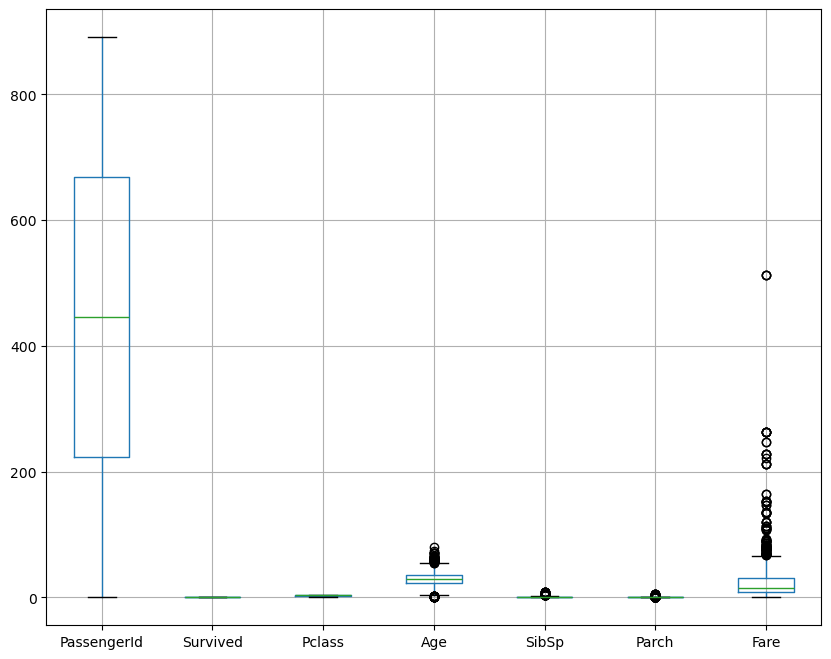

In [89]:
df.boxplot(figsize=(10,8))
plt.show()

In [90]:
df=df.drop(["PassengerId","Name","Ticket","Cabin"],axis=1)

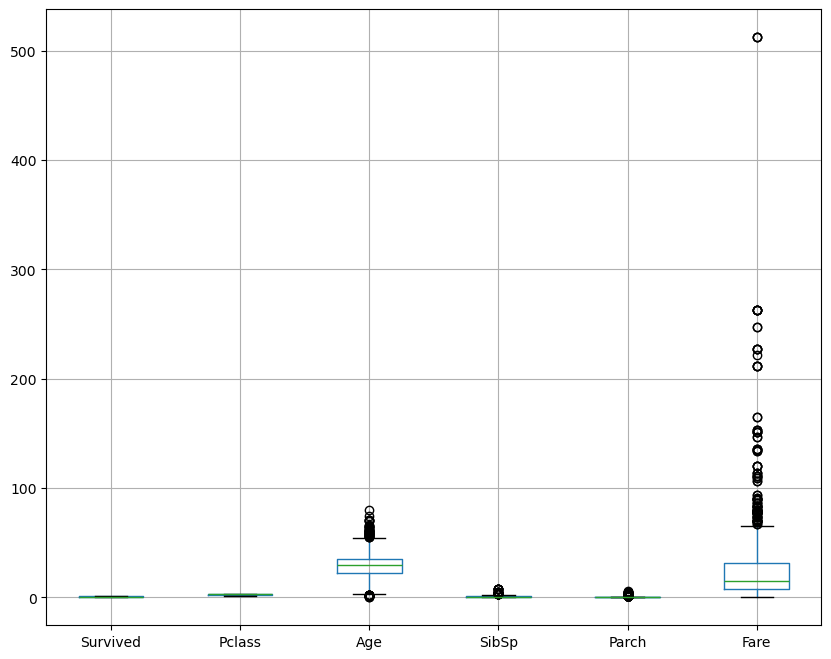

In [91]:
df.boxplot(figsize=(10,8))
plt.show()

In [92]:
df=pd.get_dummies(df,columns=["Sex","Embarked"],drop_first=True)
#convert categorial columns[sex ,embarked] into numerical columns
#drop_first=True removes one category to avoid dupliacte information

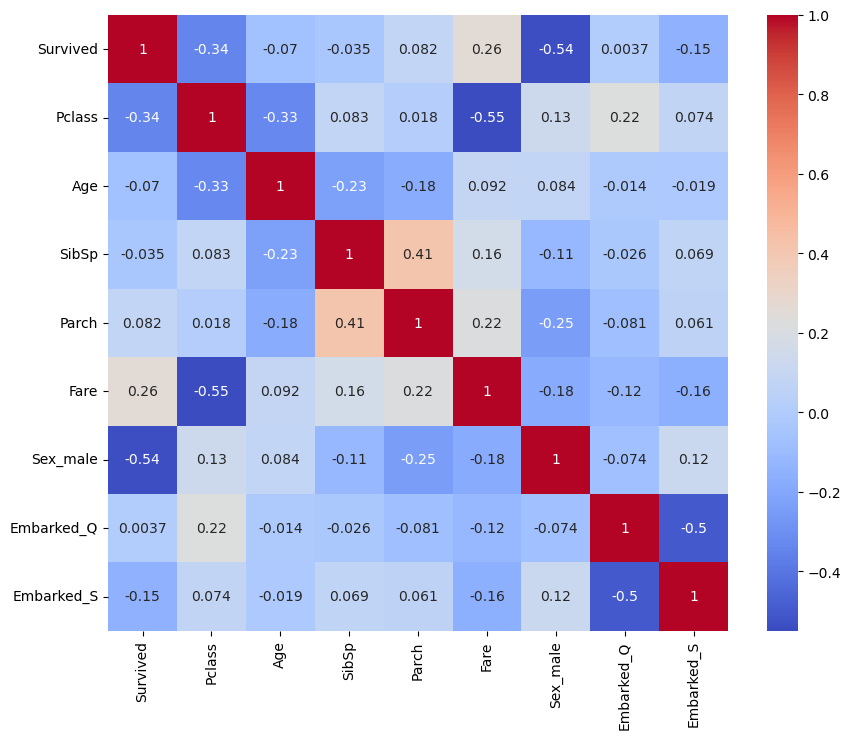

In [93]:
plt.figure(figsize=(10,8))
# creating a figure for the plot with width=10 and height=8

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
#Draw a heatmap to visualize correaltion b/w features,annot=True shows the values(numbers in each box) and coolwarm sets the coloue theme

plt.show()
#Displays the heatmap

In [94]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df["Fare"]>=lower) & (df["Fare"] <= upper)] 
print("outliers removed using iqr method")


outliers removed using iqr method


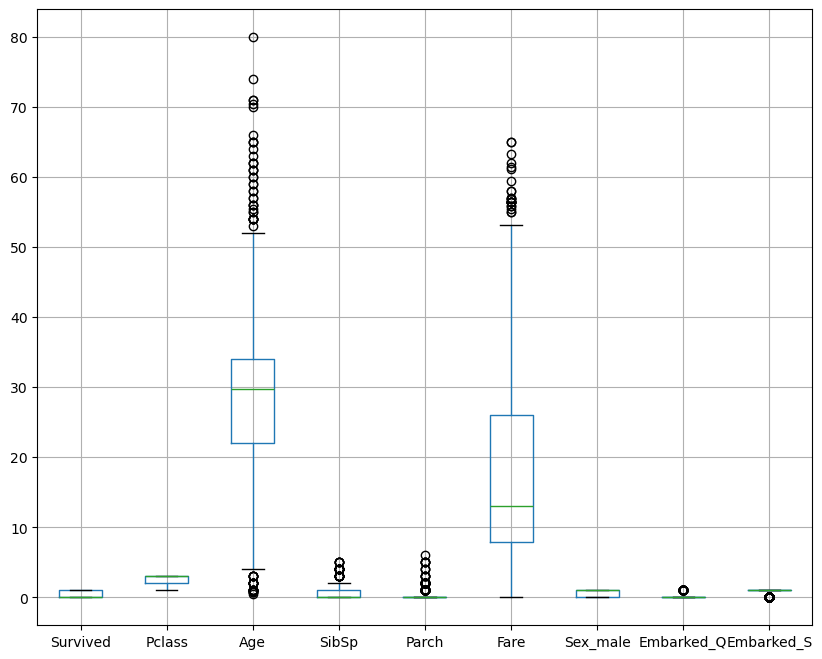

In [95]:

df.boxplot(figsize=(10,8))
plt.show()

In [96]:


# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Calculate Q1 and Q3
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Filter dataset (remove outliers)
df_clean = df[~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

print(df_clean)

     Survived  Pclass        Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0           0       3  22.000000      1      0   7.2500      True       False   
2           1       3  26.000000      0      0   7.9250     False       False   
3           1       1  35.000000      1      0  53.1000     False       False   
4           0       3  35.000000      0      0   8.0500      True       False   
5           0       3  29.699118      0      0   8.4583      True        True   
..        ...     ...        ...    ...    ...      ...       ...         ...   
884         0       3  25.000000      0      0   7.0500      True       False   
886         0       2  27.000000      0      0  13.0000      True       False   
887         1       1  19.000000      0      0  30.0000     False       False   
889         1       1  26.000000      0      0  30.0000      True       False   
890         0       3  32.000000      0      0   7.7500      True        True   

     Embarked_S  
0        

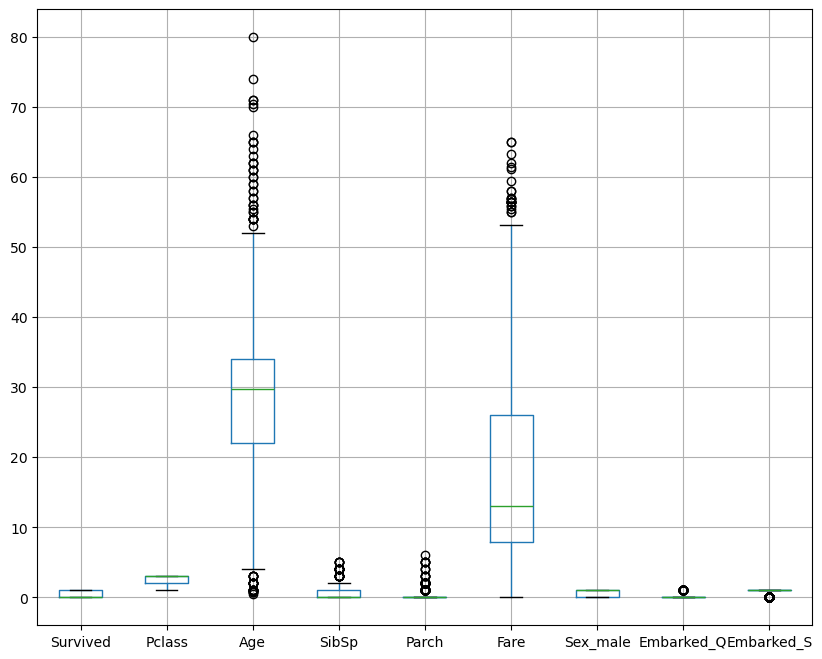

In [97]:

df.boxplot(figsize=(10,8))
plt.show()

In [98]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    775 non-null    int64  
 1   Pclass      775 non-null    int64  
 2   Age         775 non-null    float64
 3   SibSp       775 non-null    int64  
 4   Parch       775 non-null    int64  
 5   Fare        775 non-null    float64
 6   Sex_male    775 non-null    bool   
 7   Embarked_Q  775 non-null    bool   
 8   Embarked_S  775 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.7 KB
None


In [101]:

X=df.drop("Survived",axis=1)
#independent variable

Y=df["Survived"]
#target variable

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)
#splits the dataset into traiing and testing sets(test=20%),random_state fixes random split so that the same split occurs every time the code runs
#stratify=y ensures that both training and testing sets keep the same class distibution

In [100]:
print(df.describe())



         Survived     Pclass         Age       SibSp       Parch        Fare
count  775.000000  775.00000  775.000000  775.000000  775.000000  775.000000
mean     0.339355    2.48000   29.103880    0.437419    0.340645   17.822091
std      0.473796    0.73439   12.779988    0.899838    0.785914   13.578085
min      0.000000    1.00000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.00000   22.000000    0.000000    0.000000    7.895800
50%      0.000000    3.00000   29.699118    0.000000    0.000000   13.000000
75%      1.000000    3.00000   34.000000    1.000000    0.000000   26.000000
max      1.000000    3.00000   80.000000    5.000000    6.000000   65.000000


In [102]:
scaler=StandardScaler()
#Creates a scaler object to standardize the feature values

X_train=scaler.fit_transform(X_train)
#learn scaling parameters from training data and it

X_test=scaler.transform(X_test)
#applying same scaling transformation to the test data

model=LogisticRegression(max_iter=500)
#create a logistic regression model and allow more iterations for training

model.fit(X_train,Y_train)
#Train the model using training dataset

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [103]:
Y_pred=model.predict(X_test)
#predict class labels for test data

Y_prob=model.predict_proba(X_test)[:,-1]
#predicts the probability that each test sample belongs to the positive class

In [104]:
print("Accuracy: ",accuracy_score(Y_test,Y_pred))
#Displays the overall accuracy of the model

print("\nClassification Report: ")
print(classification_report(Y_test,Y_pred))
#shows precision,recall,f1-score and support

Accuracy:  0.7806451612903226

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.86      0.84       102
           1       0.70      0.62      0.66        53

    accuracy                           0.78       155
   macro avg       0.76      0.74      0.75       155
weighted avg       0.78      0.78      0.78       155



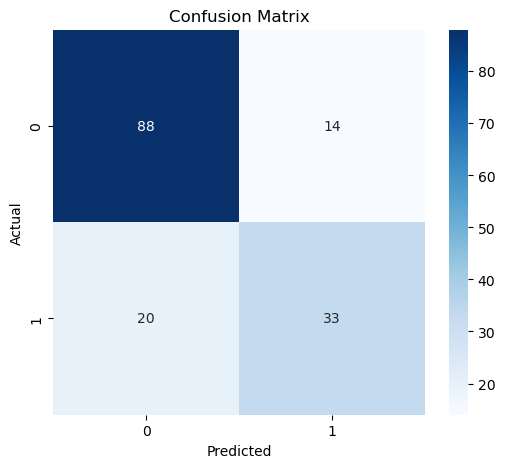

In [105]:
cm = confusion_matrix(Y_test,Y_pred)
#genertae confusion matrix to evaluate prediction performance 

plt.figure(figsize=(6,5))
#creates space for confusion matrix plot

sns.heatmap(cm,annot=True,fmt="d", cmap="Blues")
#visualize confusion matrix with values, fmt="d" - display numbers as integers(whole numbers)
#Blues - light blue for small numbers,Dark blue for large numbers

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [109]:
coeff=pd.DataFrame(model.coef_[0],index=df.columns[:-1],columns=["Coefficient"])
#store model coefficeints with feature names

coeff.sort_values("Coefficient").plot(kind="barh",figsize=(8,8))
#plot sorted coefficients to visualize with feature importance

plt.title("Feature Importance(Logistic Regression Coefficients)")
plt.show()

NameError: name 'roc_auc_score' is not defined